# Testing: name_date / year Image Classifier

## Imports

In [1]:
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

## Load Test Images

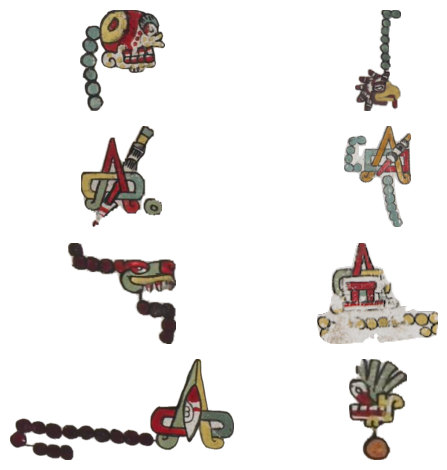

In [2]:
test_img_paths = [
                    'name_date_images/test/name_date/005-004-a-014-6death.png',
                    'name_date_images/test/name_date/013-010-a-044-8eagle.png',
                    'name_date_images/test/year/023-018-a-083-year1reed.png',
                    'name_date_images/test/year/048-028-a-137-year12reed.png',
                    'name_date_images/test/name_date/017-013-a-062-9crocodile.png',
                    'name_date_images/test/year/013-010-a-045-year13house.png',
                    'name_date_images/test/year/027-019-a-103-year13flint.png',
                    'name_date_images/test/name_date/024-019-a-084-1grass.png'                    
                    ]
for i, img in enumerate(test_img_paths):
    # Load and convert the image to an array
    image = np.asarray(Image.open(img))

    # Create a subplot for each image
    plt.subplot(4, 2, i + 1)  # +1 because subplot index starts at 1
    plt.imshow(image)
    plt.axis('off')  # Hide axes

# Adjust layout
plt.tight_layout()
plt.show()

In [3]:
from going_modular.going_modular.predictions import pred_and_plot_image
import torchvision

/Users/girishsalunke/anaconda3/envs/name-date/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load Model

In [4]:
from going_modular.going_modular.utils import load_model

model = load_model('models/namedate_year_classifier_vit_20241020_145546.pth','cpu')

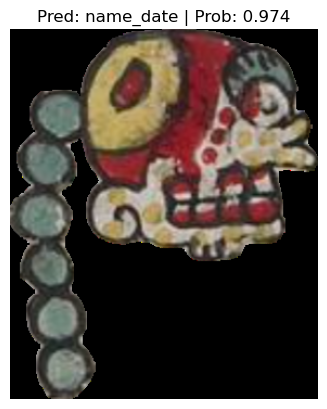

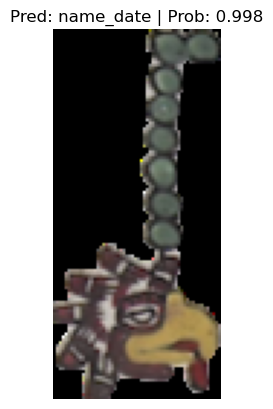

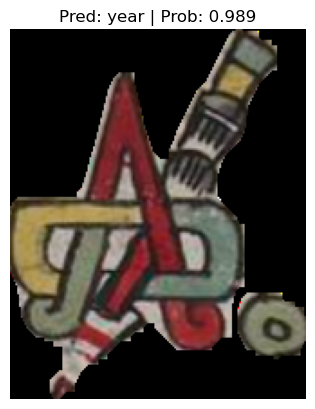

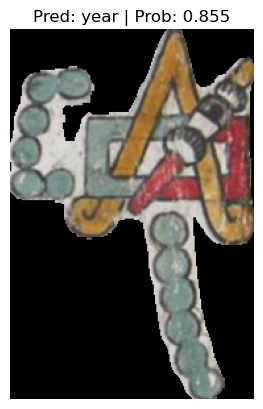

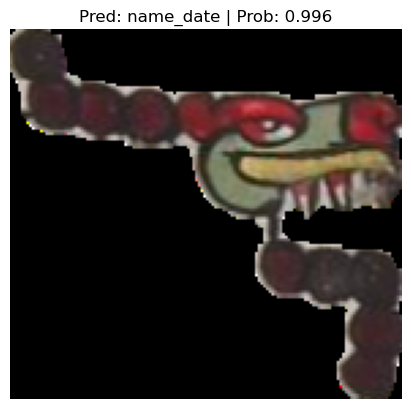

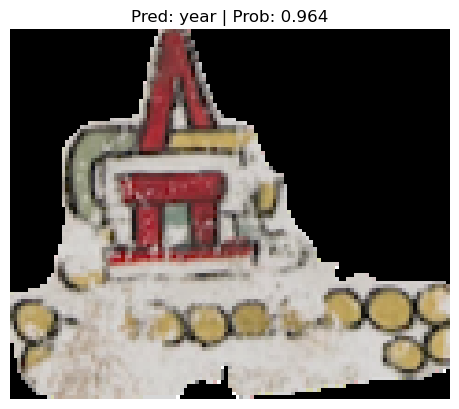

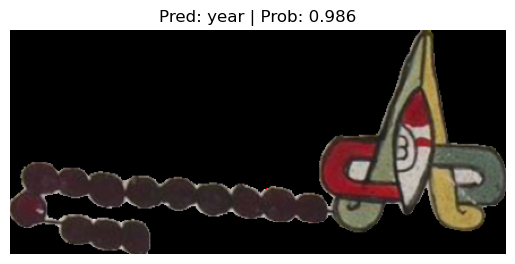

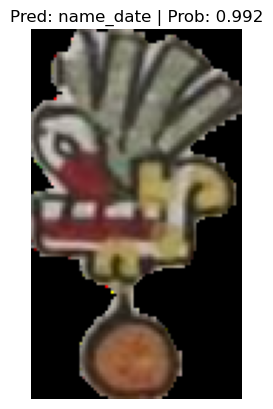

In [5]:
for i, img in enumerate(test_img_paths):
    pred_and_plot_image(model=model,
                    image_path=img,
                    class_names=["name_date", "year"],
                    )


In [51]:
from torchvision import transforms
import torch


def plot_attention_map(model, image_path, layer_idx=0, device='cuda', image_size=(224, 224)):
    # Load and preprocess the image
    img = Image.open(image_path).convert("RGB")
    
    image_transform = transforms.Compose(
        [
            transforms.Resize(image_size),
            transforms.ToTensor(),
            transforms.Normalize(
                mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
            ),
        ]
    )
    
    transformed_image = image_transform(img).unsqueeze(dim=0).to(device)

    # Register a hook to capture the attention weights
    attention_weights = []

    def get_attention_weights(module, input, output):
        attention_weights.append(output[0])  # Append only the first item (the attention weights)

    # Access the correct layer in the encoder
    layer = model.encoder.layers[layer_idx]

    # Register the hook to the self-attention module
    hook = layer.self_attention.register_forward_hook(get_attention_weights)

    # Run the model
    with torch.inference_mode():
        _ = model(transformed_image)

    # Remove the hook
    hook.remove()

    # Check if we have captured any attention weights
    if not attention_weights or attention_weights[0] is None:
        raise RuntimeError("No attention weights captured. Check if the hook was registered correctly.")

    # Process the attention weights
    attention = attention_weights[0].detach().cpu().numpy()  # Get the attention weights
    print("Attention shape:", attention.shape)  # Debugging line
    attention = attention[0]  # Take the first item in the batch

    # Check the shape and adjust the reshaping logic accordingly
    # Assuming we want to average across the heads if the attention is in shape (N, H, W)
    if len(attention.shape) == 3:
        attention = attention.reshape(attention.shape[1], attention.shape[2])  # Reshape to (H, W)
    elif len(attention.shape) == 2:
        attention = attention.reshape(1, attention.shape[0], attention.shape[1])  # Ensure it's 3D

    # Average the attention weights across heads
    attention_map = np.mean(attention, axis=0)  # Average across heads

    # Resize attention map to match image size
    attention_map_resized = torch.nn.functional.interpolate(
        torch.tensor(attention_map).unsqueeze(0).unsqueeze(0), size=img.size[::-1], mode='bilinear', align_corners=False
    ).squeeze().numpy()

    # Plot the original image and attention map
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title('Original Image')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(attention_map_resized, cmap='Reds', alpha=0.5)
    plt.title('Attention Map')
    plt.axis('off')

    plt.show()


Attention shape: (1, 197, 768)


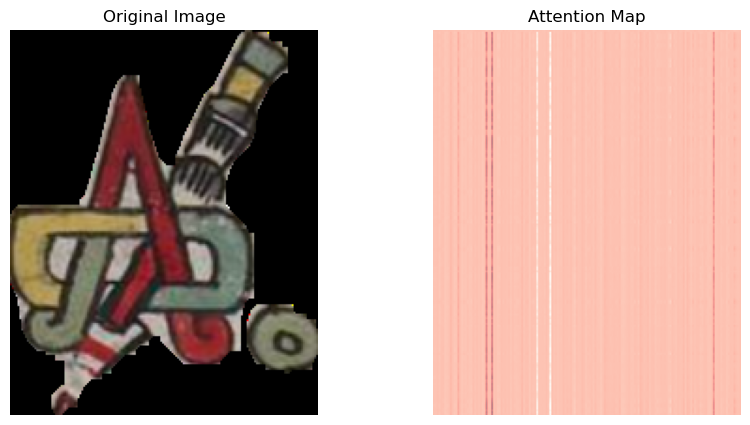

In [63]:
plot_attention_map(model, test_img_paths[2],layer_idx=11, device='cpu')

In [57]:
print(model)

VisionTransformer(
  (conv_proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
  (encoder): Encoder(
    (dropout): Dropout(p=0.0, inplace=False)
    (layers): Sequential(
      (encoder_layer_0): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
        )
        (dropout): Dropout(p=0.0, inplace=False)
        (ln_2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU(approximate=none)
          (2): Dropout(p=0.0, inplace=False)
          (3): Linear(in_features=3072, out_features=768, bias=True)
          (4): Dropout(p=0.0, inplace=False)
        )
      )
      (encoder_layer_1): EncoderBlock(
        (ln_1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (self_att